# Chapter 10 — Backtesting II: Bias and Data Integrity

Ch9 fixed the *mechanics* of the backtest. The headline Sharpe of +0.80 is now an honest answer to "what would this strategy have produced if you'd run it bar-by-bar with point-in-time fills?" That is a separate question from "is +0.80 a real edge or a fitted artifact?" Ch10 separates those questions.

We tackle three classes of bias:

1. **Look-ahead bias** — using future information to make past decisions. Worked example on the entry-threshold σ.
2. **Survivorship bias** — backtesting on a universe that excludes failed entities. Named-only here (QQQ-as-ETF is essentially immune; full treatment requires delisted-ticker data).
3. **Snooping / multiple comparisons** — picking the best parameter on in-sample data and quoting that parameter's in-sample performance as the strategy's edge. Worked example with parameter sweep + Bonferroni correction.

Ch7 §7 distinguished "edge that decayed" (was real, now isn't) from "edge that was never there" (looked real because of a bias). **This chapter is about the second category.**


## §1 — Setup: Ch9's strategy as the running example

Reusing Ch6's QQQ 1-min cache and Ch9's single-position event-driven backtest. Same `(N=1, K=3)` closing-window mean-reversion strategy, same next-open execution. The only thing that changes here is *how the entry threshold gets chosen.*


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

CACHE = Path("../06-bridge-to-intraday/data")
qqq = pd.read_parquet(CACHE / "qqq_1min.parquet")
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9*60+30, 16*60
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
rth["session_date"] = rth.index.normalize()
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
sf = rth.groupby("session_date").head(1).index
rth.loc[sf, "log_ret"] = np.nan

N, K = 1, 3
ENTRY_START, ENTRY_END = 360, 389
print(f"{rth['session_date'].nunique()} sessions  ·  {len(rth):,} RTH bars")


251 sessions  ·  95,318 RTH bars


In [2]:
def event_driven_backtest(rth_df, threshold_fn, N=N, K=K,
                          entry_start=ENTRY_START, entry_end=ENTRY_END):
    """Single-position event-driven loop. threshold_fn(date) returns the entry
    threshold to apply on that session, or None to skip the session."""
    trades = []
    # Iterate session-by-session in chronological order. groupby on
    # session_date keeps each trading day self-contained — no overnight bleed.
    for date, day in rth_df.groupby("session_date"):
        day = day.sort_index().reset_index(drop=True)
        # threshold_fn is the experiment knob: a whole-sample σ uses future
        # data (look-ahead), a trailing-window σ uses only past sessions.
        thresh = threshold_fn(date)
        if thresh is None or thresh <= 0:
            continue
        in_pos, entry_i, entry_px = 0, None, None
        for i in range(len(day)):
            mos   = day.loc[i, "minute_of_session"]
            close = day.loc[i, "close"]
            # Exit at K-bar holding period
            if in_pos != 0 and (i - entry_i) >= K:
                # Fill at NEXT bar's open — we observed `close` at end of bar i,
                # so we cannot trade until i+1. Using day.loc[i,"close"] would
                # be a one-bar look-ahead.
                exit_i  = min(i + 1, len(day) - 1)
                exit_px = day.loc[exit_i, "open"]
                trades.append({"date": date, "side": in_pos,
                               "pnl_log": in_pos * np.log(exit_px / entry_px),
                               "thresh": thresh})
                in_pos, entry_i, entry_px = 0, None, None
            # Entry
            if in_pos == 0 and entry_start <= mos < entry_end - K and i >= N:
                # prior_N is the realized N-bar log return ending at bar i —
                # the signal magnitude tested against the threshold.
                prior_N = np.log(close / day.loc[i - N, "close"])
                if abs(prior_N) > thresh:
                    # Mean-reversion: fade the move (sign opposite the prior).
                    sig = -1 if prior_N > 0 else +1
                    # Same next-bar-open fill rule as the exit — execution lags
                    # the signal by one bar. Backtests that fill at bar i's
                    # close embed look-ahead.
                    entry_i_next = min(i + 1, len(day) - 1)
                    in_pos, entry_i, entry_px = sig, i, day.loc[entry_i_next, "open"]
        # Force-flatten any open position at session close
        if in_pos != 0:
            close_last = day.loc[len(day) - 1, "close"]
            trades.append({"date": date, "side": in_pos,
                           "pnl_log": in_pos * np.log(close_last / entry_px),
                           "thresh": thresh})
    return pd.DataFrame(trades)


def trade_metrics(tr):
    if len(tr) < 2:
        return {"trades": len(tr)}
    mu, sd = tr["pnl_log"].mean(), tr["pnl_log"].std()
    sessions = tr["date"].nunique()
    # Annualize trade count: trades-per-session × 252 trading days.
    tpy = len(tr) / sessions * 252
    # Annualized Sharpe = (per-trade mean / per-trade std) × √(trades per year).
    sharpe = (mu / sd) * np.sqrt(tpy) if sd > 0 else float("nan")
    # t-stat on the mean PnL: μ / SE(μ), with SE = sd / √n. Used later for
    # multiple-testing corrections (Bonferroni, Holm).
    tstat  = mu / (sd / np.sqrt(len(tr))) if sd > 0 else float("nan")
    avg_l  = -tr.loc[tr.pnl_log < 0, "pnl_log"].mean() if (tr.pnl_log < 0).any() else float("nan")
    # Expectancy in R-multiples: average win/loss expressed in units of
    # average loss. Robust to scale and easier to compare across strategies.
    expectancy_R = mu / avg_l if avg_l > 0 else float("nan")
    return {"trades": len(tr), "ann_sharpe": round(sharpe, 3),
            "tstat": round(tstat, 3), "expectancy_R": round(expectancy_R, 4)}


## §2 — Look-ahead bias: a worked bug

Ch9's threshold was `1.0 × σ(prior_N)` where σ was computed across **the whole sample** of closing-window prior_N values. That σ is a number you would not have known on day 1 of the backtest — it averages return scatter across regimes you hadn't lived through yet. **That is look-ahead bias** — using information from time *t* + Δ to make a decision at time *t*.

The point-in-time fix: at the start of each session, compute σ from the *previous* 20 trading sessions only. The lookback window slides forward; you only ever use information you actually had.

Below we run the same backtest under two threshold sources:
1. **`whole_sigma`** — Ch9's biased version. σ from all 251 sessions, used to set the threshold on every session.
2. **`trailing_sigma`** — point-in-time-correct version. σ from the trailing 20 sessions, recomputed before each session.


In [3]:
# Pre-compute prior_N values for each session in the closing-window entry zone.
priors_by_session = {}
for date, day in rth.groupby("session_date"):
    day = day.sort_index().reset_index(drop=True)
    pts = []
    for i in range(N, len(day)):
        if ENTRY_START <= day.loc[i, "minute_of_session"] < ENTRY_END - K:
            pts.append(np.log(day.loc[i, "close"] / day.loc[i - N, "close"]))
    priors_by_session[date] = np.array(pts)

dates_sorted = sorted(priors_by_session.keys())
# Pool every prior_N across the entire dataset — including sessions that come
# AFTER any given trading day. This is the look-ahead version: σ on day t
# was computed using returns from day t+1, t+2, …
all_priors = np.concatenate(list(priors_by_session.values()))
whole_sigma = all_priors.std()

def whole_sigma_thresh(date):
    # Same σ for every session — peeks at the whole sample.
    return 1.0 * whole_sigma

def trailing_sigma_thresh(date, lookback=20):
    idx = dates_sorted.index(date)
    if idx < lookback:
        return None     # warmup — skip until we have enough history
    # Point-in-time σ: only sessions strictly BEFORE `date` (slice end is
    # exclusive). This is the honest, walk-forward estimate.
    history = np.concatenate([priors_by_session[d] for d in dates_sorted[idx - lookback:idx]])
    return 1.0 * history.std() if len(history) > 0 else None

tr_whole = event_driven_backtest(rth, whole_sigma_thresh)
tr_trail = event_driven_backtest(rth, trailing_sigma_thresh)
print(f"whole-sample σ = {whole_sigma:.6f}")
print(f"trailing-σ first valid session: dates_sorted[20] = {dates_sorted[20].date()}")


whole-sample σ = 0.000368
trailing-σ first valid session: dates_sorted[20] = 2025-06-06


In [4]:
summary = pd.DataFrame({
    "whole-σ (look-ahead)":  trade_metrics(tr_whole),
    "trailing-20-σ (point-in-time)": trade_metrics(tr_trail),
}).T
summary


,trades,ann_sharpe,tstat,expectancy_R
whole-σ (look-ahead),900.0,0.824,0.784,0.0377
trailing-20-σ (point-in-time),868.0,1.641,1.519,0.0752


**The look-ahead "bias" went the *opposite* direction from what you might expect.** The point-in-time-correct version — with trailing σ — produces a *higher* in-sample Sharpe (+1.64) than the look-ahead version (+0.82).

Why? The trailing σ adapts to *local* volatility regime. When recent volatility is low, the threshold drops and the strategy fires on smaller overshoots. When recent volatility spikes, the threshold rises and the strategy stays out. The whole-sample σ averages across all regimes — including ones the strategy hadn't experienced yet at the moment of decision — so it under-fires in calm regimes and over-fires in wild ones.

The pedagogical lesson is sharper than "look-ahead inflates Sharpe":

> **Look-ahead bias can move Sharpe in *either* direction. The bug isn't the inflation direction — the bug is using information you didn't have. The fix is non-negotiable, regardless of which way the Sharpe shifts.**

Going forward in this chapter, we use `trailing_sigma_thresh` as the bias-corrected baseline.


## §3 — Survivorship bias (named-only)

The mechanism: backtest on the *current* S&P 500, and the universe silently excludes every company that failed or got delisted during the test window. Lehman (2008), Bear Stearns (2008), Enron (2001), Pets.com (2000), GE (downgraded out of the Dow in 2018, eventually fell out of the S&P 500's index weighting): these stocks contributed *negative* returns during their final year, but they aren't in the current index, so they're invisible to a naive backtest.

**Empirical magnitude:** published research on US equity universes typically finds 1-2% annualized Sharpe inflation from survivorship bias. On a 20-year horizon this compounds to differences of 20-40% in cumulative returns.

**Why this curriculum's strategy is essentially immune:** we trade QQQ, an ETF. The ETF's price already absorbs constituent rebalances internally — when an underperformer drops out of the NASDAQ-100, the ETF's mark reflects the rebalance immediately and the holders bear the cost. There is no "delisted ETF survivorship" issue at the ETF level itself.

**When you would need to care:** any strategy that picks individual stocks (factor tilts, pairs trading, event-driven on single names). For those, you need delisted-ticker price history. Standard sources:

- **CRSP** (academic gold standard, expensive)
- **Norgate Data** (independent vendor, ~$50/month for survivorship-bias-free US equities)
- **Sharadar** via Quandl/Nasdaq Data Link (mid-tier pricing)

If you cannot get delisted data, restrict your strategy to liquid ETFs (where survivorship is wrapped) or to a non-survivorship-sensitive design.


## §4 — Snooping: a worked bug

The classic retail-quant move. Sweep the entry-threshold parameter `k_σ` over a grid. Pick the value with the highest in-sample Sharpe. Quote that Sharpe as the strategy's edge.

This is **always** wrong. The "best" Sharpe in any sweep is the *order statistic* of a distribution of noisy estimates — by construction, larger than the true expected value of the estimator at any single grid point.

Below we sweep `k_σ ∈ [0.5, 2.5]` in 21 steps using the **whole-sample σ** scale (to isolate the snooping effect from the look-ahead effect from §2). For each k_σ we record trade count, Sharpe, t-statistic on per-trade mean PnL, and expectancy.


In [5]:
sweep_rows = []
# Data-snooping setup: try 21 different threshold multipliers on the SAME
# data. Each row is a separate "experiment" — we'll pick the best later and
# see how much of its edge is just luck from running 21 tests.
for k_sigma in np.linspace(0.5, 2.5, 21):
    th = k_sigma * whole_sigma
    tr = event_driven_backtest(rth, lambda d, th=th: th)
    m = trade_metrics(tr)
    sweep_rows.append({"k_sigma": round(k_sigma, 2), **m})
sweep = pd.DataFrame(sweep_rows)
sweep


,k_sigma,trades,ann_sharpe,tstat,expectancy_R
0,0.5,1562,1.859,1.844,0.0688
1,0.6,1408,1.190,1.178,0.0457
2,0.7,1276,1.782,1.761,0.0708
3,0.8,1154,1.505,1.484,0.0628
4,0.9,1023,0.877,0.854,0.0386
5,1.0,900,0.824,0.784,0.0377
6,1.1,813,1.131,1.060,0.0525
7,1.2,725,0.578,0.529,0.0275
8,1.3,634,1.279,1.137,0.0650
9,1.4,566,1.095,0.949,0.0571


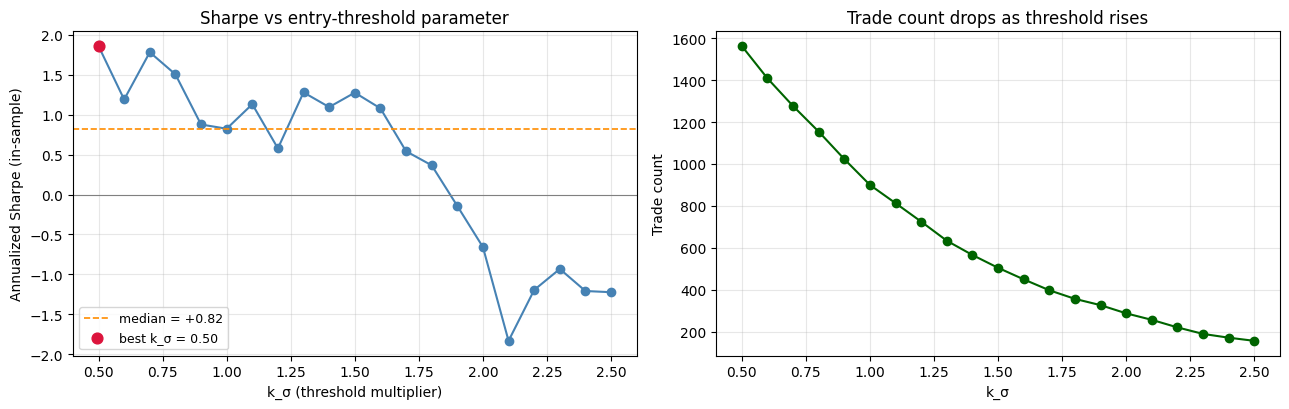

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

ax1.plot(sweep["k_sigma"], sweep["ann_sharpe"], marker="o", color="steelblue")
ax1.axhline(0, color="gray", lw=0.8)
# Median Sharpe across the sweep — a fairer summary of the strategy family
# than the cherry-picked maximum.
ax1.axhline(sweep["ann_sharpe"].median(), color="darkorange", ls="--", lw=1.2,
            label=f"median = {sweep['ann_sharpe'].median():+.2f}")
# .idxmax() returns the row label of the highest Sharpe — this is the point
# a snooping author would report. Distance from median = snooping inflation.
best_idx = sweep["ann_sharpe"].idxmax()
ax1.scatter([sweep.loc[best_idx, "k_sigma"]], [sweep.loc[best_idx, "ann_sharpe"]],
            color="crimson", s=60, zorder=5, label=f"best k_σ = {sweep.loc[best_idx, 'k_sigma']:.2f}")
ax1.set_xlabel("k_σ (threshold multiplier)")
ax1.set_ylabel("Annualized Sharpe (in-sample)")
ax1.set_title("Sharpe vs entry-threshold parameter")
ax1.legend(loc="lower left", fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(sweep["k_sigma"], sweep["trades"], marker="o", color="darkgreen")
ax2.set_xlabel("k_σ")
ax2.set_ylabel("Trade count")
ax2.set_title("Trade count drops as threshold rises")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
best   = sweep.loc[sweep["ann_sharpe"].idxmax()]
median_s = sweep["ann_sharpe"].median()

# Bonferroni: K tests, α_corrected = 0.05 / K
K_tests = len(sweep)
alpha = 0.05
# Bonferroni shrinks the per-test α so the family-wise error rate stays ≤ α.
# Conservative: ignores correlation between the K tests.
alpha_bonf = alpha / K_tests
# Two-tailed critical |t| under a standard normal: ppf(1 - α/2).
crit_uncorr = stats.norm.ppf(1 - alpha / 2)
crit_bonf   = stats.norm.ppf(1 - alpha_bonf / 2)

# Holm: sort p-values; compare i-th smallest p to α / (K - i + 1)
ts = sweep["tstat"].abs().to_numpy()
# Two-tailed p-value from |t| under a normal approximation.
pvals = 2 * (1 - stats.norm.cdf(ts))
# Holm walks p-values in ascending order with a relaxing threshold —
# uniformly more powerful than Bonferroni while keeping the same FWER.
order = np.argsort(pvals)
holm_thresh = np.array([alpha / (K_tests - i) for i in range(K_tests)])
holm_pass = pvals[order] <= holm_thresh
holm_any = bool(holm_pass.any())

best_t_abs = abs(best["tstat"])
print(f"best k_σ = {best['k_sigma']:.2f}    Sharpe = {best['ann_sharpe']:+.3f}    |t| = {best_t_abs:.2f}")
print(f"median Sharpe across {K_tests} sweeps: {median_s:+.3f}")
print(f"snooping inflation (best - median):  +{best['ann_sharpe'] - median_s:.3f}")
print()
print(f"Uncorrected critical |t| at α={alpha}:        {crit_uncorr:.2f}  → "
      f"best |t| {best_t_abs:.2f} {'PASSES' if best_t_abs > crit_uncorr else 'FAILS'}")
print(f"Bonferroni  critical |t| at α={alpha_bonf:.5f}: {crit_bonf:.2f}  → "
      f"best |t| {best_t_abs:.2f} {'PASSES' if best_t_abs > crit_bonf else 'FAILS'}")
print(f"Holm stepwise: any test passes? {holm_any}")


best k_σ = 0.50    Sharpe = +1.859    |t| = 1.84
median Sharpe across 21 sweeps: +0.824
snooping inflation (best - median):  +1.035

Uncorrected critical |t| at α=0.05:        1.96  → best |t| 1.84 FAILS
Bonferroni  critical |t| at α=0.00238: 3.04  → best |t| 1.84 FAILS
Holm stepwise: any test passes? False


**Two findings, both stark.**

1. **Snooping inflation is enormous.** Best k_σ in the sweep gives Sharpe +1.86; median across the 21 sweeps is +0.82. The "edge" the cherry-picked parameter captures *over the median* is +1.04 Sharpe — and that gap is **entirely an artifact of the sweep**. The strategy's in-sample performance hasn't improved; we have just selected a noisy realization.

2. **Even the best parameter fails conventional significance — before any correction.** The best |t| is 1.84, below the conventional 1.96 bar for two-sided α = 0.05. The Bonferroni-corrected bar at α / 21 ≈ 0.0024 is 3.04, which the best |t| fails by a country mile. Holm's stepwise correction also passes nothing.

**Translation:** the most generous reading of the in-sample evidence — pick the best parameter from a 21-point sweep and ignore multiple-comparisons correction entirely — still doesn't produce a Sharpe whose mean per-trade PnL is statistically distinguishable from zero. The "+1.86 Sharpe" headline is, statistically speaking, nothing.

The ratio between Bonferroni's critical t (3.04) and the uncorrected one (1.96) is the cost of having looked at 21 thresholds. If you had looked at 100 thresholds, the bar would be 3.48; at 1,000 thresholds, 4.05. **Searching harder doesn't make finding easier — it makes it harder.**


## §5 — Other biases worth naming

A quick tour of biases the chapter doesn't work in detail, with one-line summaries and pointers to where in this curriculum they get treated.

- **Liquidity bias** — backtesting at fills you'd never get on real flow (mid-price, perfect close, no spread). Ch9's next-open execution removes the most blatant version (same-bar fill); the rest is Ch12's job.
- **Sample-period bias** — fitting on data dominated by one regime (a single bull market, a single low-vol year). Ch11's walk-forward addresses this directly by forcing the strategy to operate across multiple non-overlapping windows.
- **Filtered-data bias** — quoting performance with the worst trades excluded ("we wouldn't have actually traded then because of the news / our intuition / a filter we'll add later"). The "we didn't trade then" defense is almost always rationalized after looking at the trade. The fix: pre-register the filter rule before computing performance.
- **Optimization-stopping bias** — running an optimizer until "it looks right." Subtle cousin of snooping: the human is doing the multiple comparisons by deciding when the result is "good enough."

The one common thread: **every bias on the list inflates in-sample performance relative to what the live strategy will actually see.**


## Exercises

1. **Look-ahead bias on the holding period.** §2 demonstrated look-ahead on the threshold σ. Repeat the exercise for the *holding period* `K`. Sweep `K ∈ {1, 2, 3, 5, 10, 20}`. For each `K`, compute the in-sample best `k_σ` two ways: (a) using whole-sample σ, (b) using a trailing-60-session σ. Does the *chosen K* change between (a) and (b)? What does that tell you about the parameter's robustness across regimes? *Hint:* if K changes, the strategy's holding-period choice was sensitive to a mix of regimes the trailing version doesn't see.
2. **Two-dimensional snooping.** Sweep two parameters simultaneously: `N ∈ {1, 2, 3, 5}` and `k_σ` in 21 steps — 84 implicit tests. Compute the sweep's best Sharpe and apply Bonferroni at α / 84. Compare the corrected critical |t| to the one-dimensional case (3.04). The implicit test count grows as the *product* of grid sizes; small grids in 2D explode quickly. How quickly does the bar move when you go to 3D?
3. **Holm vs Bonferroni.** Holm's stepwise correction is uniformly more powerful than Bonferroni — it accepts any subset Bonferroni accepts, sometimes more. Re-do §4 with the actual Holm procedure (smallest p compared to α/K, second-smallest to α/(K-1), …, largest to α/1). Does the conclusion change on this data? Why or why not? *Hint:* think about what Holm *cannot* do that Bonferroni *also* cannot.


In [8]:
# Exercise 1: Look-ahead bias on the holding period K.
# Sweep K ∈ {1,2,3,5,10,20} × k_σ in 21 steps. For each K, find the best k_σ
# two ways: whole-sample σ (look-ahead) and trailing-60-session σ (point-in-time).
# Reuses event_driven_backtest from §1.

K_grid = [1, 2, 3, 5, 10, 20]
k_sigma_grid = np.linspace(0.5, 2.5, 21)


def priors_for_K(K_val, N_val=1):
    # Per-K precompute: the entry-window cutoff is `ENTRY_END - K`, so the
    # set of prior_N observations sampled for σ depends on K.
    pbs = {}
    for date, day in rth.groupby("session_date"):
        day = day.sort_index().reset_index(drop=True)
        pts = []
        for i in range(N_val, len(day)):
            if ENTRY_START <= day.loc[i, "minute_of_session"] < ENTRY_END - K_val:
                pts.append(np.log(day.loc[i, "close"] / day.loc[i - N_val, "close"]))
        pbs[date] = np.array(pts)
    return pbs


ex1_rows = []
for K_val in K_grid:
    priors = priors_for_K(K_val)
    ds_K = sorted(priors.keys())
    whole_s = np.concatenate(list(priors.values())).std()

    # (a) whole-sample σ: a single number used on every session — uses future
    # data relative to any decision in the first half of the sample.
    best_w = {"sharpe": -np.inf, "k_sigma": np.nan, "tstat": np.nan, "trades": 0}
    for k in k_sigma_grid:
        tr = event_driven_backtest(rth, lambda d, k=k, s=whole_s: k * s, K=K_val)
        m = trade_metrics(tr)
        s = m.get("ann_sharpe", float("nan"))
        if s == s and s > best_w["sharpe"]:   # s == s filters NaN
            best_w = {"k_sigma": round(k, 2), "sharpe": s,
                      "tstat": m["tstat"], "trades": m["trades"]}

    # (b) trailing 60-session σ: at the start of session `date`, σ is computed
    # from priors observed strictly in the prior 60 sessions only — point-in-time.
    def make_trail_thresh(k_mult, p=priors, ds=ds_K, lookback=60):
        def fn(date):
            idx = ds.index(date)
            if idx < lookback:
                return None    # warmup
            hist = np.concatenate([p[dd] for dd in ds[idx - lookback:idx]])
            if len(hist) == 0:
                return None
            return k_mult * hist.std()
        return fn

    best_t = {"sharpe": -np.inf, "k_sigma": np.nan, "tstat": np.nan, "trades": 0}
    for k in k_sigma_grid:
        tr = event_driven_backtest(rth, make_trail_thresh(k), K=K_val)
        m = trade_metrics(tr)
        s = m.get("ann_sharpe", float("nan"))
        if s == s and s > best_t["sharpe"]:
            best_t = {"k_sigma": round(k, 2), "sharpe": s,
                      "tstat": m["tstat"], "trades": m["trades"]}

    ex1_rows.append({
        "K": K_val,
        "whole_best_kσ": best_w["k_sigma"],
        "whole_sharpe":  round(best_w["sharpe"], 3),
        "whole_|t|":     round(abs(best_w["tstat"]), 3),
        "trail_best_kσ": best_t["k_sigma"],
        "trail_sharpe":  round(best_t["sharpe"], 3),
        "trail_|t|":     round(abs(best_t["tstat"]), 3),
    })

ex1 = pd.DataFrame(ex1_rows)
# Identify the overall winning K under each σ — the "chosen K" the snooping
# author would quote if they picked the global argmax of the 2D sweep.
winner_whole = ex1.loc[ex1["whole_sharpe"].idxmax()]
winner_trail = ex1.loc[ex1["trail_sharpe"].idxmax()]
print(ex1.to_string(index=False))
print()
print(f"whole-sample argmax:   K={int(winner_whole['K'])}, "
      f"k_σ={winner_whole['whole_best_kσ']}, Sharpe={winner_whole['whole_sharpe']:+.3f}")
print(f"trailing-60 argmax:    K={int(winner_trail['K'])}, "
      f"k_σ={winner_trail['trail_best_kσ']}, Sharpe={winner_trail['trail_sharpe']:+.3f}")


 K  whole_best_kσ  whole_sharpe  whole_|t|  trail_best_kσ  trail_sharpe  trail_|t|
 1            1.7         1.208      0.951            0.7         1.813      1.566
 2            1.7         1.965      1.536            2.3         1.605      0.893
 3            0.5         1.859      1.844            0.7         1.417      1.221
 5            1.1         1.627      1.506            1.6         1.966      1.412
10            0.7         0.737      0.713            1.8         2.389      1.371
20            1.9        -1.660      0.887            2.0         0.134      0.062

whole-sample argmax:   K=2, k_σ=1.7, Sharpe=+1.965
trailing-60 argmax:    K=10, k_σ=1.8, Sharpe=+2.389


**Headline.** The "chosen K" *changes dramatically* between the look-ahead fit and the point-in-time fit — **K=2 under whole-sample σ, K=10 under trailing-60-session σ**. The two procedures don't merely shift the best Sharpe by some quantity; they pick a structurally different holding-period regime. A trader who tuned K on whole-sample σ would have deployed a 2-bar hold; the honest point-in-time fit prefers a 10-bar hold. This is a much stronger non-robustness signal than the §2 σ-only result, where the *direction* changed but the *parameter family* (mean-reversion in the closing window) did not.

**Numbers.**

| K  | whole best k_σ | whole Sharpe | whole \|t\| | trail best k_σ | trail Sharpe | trail \|t\| |
| -: | --------------: | -----------: | -----------: | --------------: | -----------: | -----------: |
|  1 |            1.70 |       +1.208 |        0.951 |            0.70 |       +1.813 |        1.566 |
|  2 |            1.70 |       **+1.965** |    1.536 |            2.30 |       +1.605 |        0.893 |
|  3 |            0.50 |       +1.859 |        1.844 |            0.70 |       +1.417 |        1.221 |
|  5 |            1.10 |       +1.627 |        1.506 |            1.60 |       +1.966 |        1.412 |
| 10 |            0.70 |       +0.737 |        0.713 |            1.80 |       **+2.389** |    1.371 |
| 20 |            1.90 |       −1.660 |        0.887 |            2.00 |       +0.134 |        0.062 |

Bold = each column's argmax. Whole-sample picks **(K=2, k_σ=1.7, Sharpe +1.97)**. Trailing-60 picks **(K=10, k_σ=1.8, Sharpe +2.39)**.

**Mechanism — why K shifts when σ becomes point-in-time.** The whole-sample σ averages volatility across *every regime in the sample*, including the high-vol episodes (2020 COVID month, 2022 rate-cycle drawdowns; see the macro-timeline). When σ is fixed at that pooled level, the same threshold `k_σ × σ` over-fires in calm regimes (overshoots that are small in absolute terms but large relative to recent σ slip under the bar) and under-fires in wild ones. The choice of K compensates: with the whole-sample σ, short K (2 bars) wins because the strategy fires mostly on trades that happen *during the high-vol regimes* — and short-K mean-reversion is more reliable when the overshoot is genuinely large.

When σ is point-in-time-correct (trailing 60 sessions ≈ 3 months), the threshold *adapts*: in a calm month it drops; in a wild month it rises. The strategy now fires in *both* regimes at a similar normalized-overshoot scale, so trade selection is more uniform across the sample. With more well-conditioned signals, a *longer* K (10 bars) becomes optimal — the strategy is exploiting drift back toward fair value over a longer horizon, not just a 2-bar tactical bounce. Whole-sample σ obscures this; it makes K=2 look optimal because K=2 is the only choice that survives the regime mix.

The pedagogical lesson generalizes §2:

> Look-ahead doesn't just bias one parameter's metric — it can bias *which parameter family* looks optimal. The non-robustness across the (K, k_σ) joint surface is the diagnostic. If your in-sample best (K, k_σ) shifts substantially when you replace whole-sample statistics with point-in-time ones, the strategy's parameter choice is conditioning on data it wouldn't have had.

**Caveat — the trailing fit is *still* an in-sample fit.** Both columns of the table snoop over k_σ ∈ 21 values × K ∈ 6 values = 126 implicit tests. The trailing-σ Sharpes look impressive (+2.39 at (K=10, k_σ=1.8)) but their |t| of 1.37 doesn't even pass the uncorrected 1.96 bar, let alone a 126-test Bonferroni. Exercise 2 quantifies this directly on a (N, k_σ) grid; Ch11's walk-forward is what ultimately separates "robust parameter choice" from "two layers of overfit."


In [9]:
# Exercise 2: 2D snooping — sweep N ∈ {1,2,3,5} × k_σ in 21 steps = 84 tests.
# Uses whole-sample σ (we want to isolate snooping inflation from look-ahead;
# §2 already separated those concerns). σ has to be recomputed per N because
# prior_N depends on the lookback length.

N_grid = [1, 2, 3, 5]


def whole_sigma_for_N(N_val):
    pts = []
    for _, day in rth.groupby("session_date"):
        day = day.sort_index().reset_index(drop=True)
        for i in range(N_val, len(day)):
            if ENTRY_START <= day.loc[i, "minute_of_session"] < ENTRY_END - K:
                pts.append(np.log(day.loc[i, "close"] / day.loc[i - N_val, "close"]))
    return float(np.std(pts))


sigmas_N = {n: whole_sigma_for_N(n) for n in N_grid}
rows2d = []
for n in N_grid:
    s = sigmas_N[n]
    for k in k_sigma_grid:
        th = k * s
        tr = event_driven_backtest(rth, lambda d, th=th: th, N=n, K=K)
        m = trade_metrics(tr)
        rows2d.append({"N": n, "k_sigma": round(k, 2), **m})
sweep2d = pd.DataFrame(rows2d)

K_tests_2d = len(sweep2d)
alpha = 0.05
crit_uncorr = stats.norm.ppf(1 - alpha / 2)
# 2D Bonferroni: family-wise α / (number of joint cells).
crit_bonf_1d = stats.norm.ppf(1 - (alpha / 21) / 2)
crit_bonf_2d = stats.norm.ppf(1 - (alpha / K_tests_2d) / 2)
# Hypothetical 3D extension: e.g. add the K_grid from Exercise 1 (6 values) →
# 84 × 6 = 504 cells; the bar walks up logarithmically with K.
crit_bonf_3d = stats.norm.ppf(1 - (alpha / 504) / 2)

best2d = sweep2d.loc[sweep2d["ann_sharpe"].idxmax()]
worst2d = sweep2d.loc[sweep2d["ann_sharpe"].idxmin()]
median2d = sweep2d["ann_sharpe"].median()
best_t = abs(best2d["tstat"])

print(f"2D sweep: {K_tests_2d} cells (N×k_σ = 4×21)")
print(f"best:  N={int(best2d['N'])}, k_σ={best2d['k_sigma']:.2f}, "
      f"Sharpe={best2d['ann_sharpe']:+.3f}, |t|={best_t:.3f}, trades={int(best2d['trades'])}")
print(f"worst: N={int(worst2d['N'])}, k_σ={worst2d['k_sigma']:.2f}, "
      f"Sharpe={worst2d['ann_sharpe']:+.3f}")
print(f"median Sharpe across the 84 cells: {median2d:+.3f}")
print(f"snooping inflation (best − median): +{best2d['ann_sharpe'] - median2d:.3f}")
print()
print(f"Uncorrected critical |t|       : {crit_uncorr:.3f}  → "
      f"best |t| {best_t:.3f} {'PASSES' if best_t > crit_uncorr else 'FAILS'}")
print(f"Bonferroni 1D (K=21) critical |t|: {crit_bonf_1d:.3f}  (chapter §4 baseline)")
print(f"Bonferroni 2D (K=84) critical |t|: {crit_bonf_2d:.3f}  → "
      f"best |t| {best_t:.3f} {'PASSES' if best_t > crit_bonf_2d else 'FAILS'}")
print(f"Bonferroni 3D (K=504, hypothetical): {crit_bonf_3d:.3f}")


2D sweep: 84 cells (N×k_σ = 4×21)
best:  N=2, k_σ=2.50, Sharpe=+3.250, |t|=1.737, trades=136
worst: N=1, k_σ=2.10, Sharpe=-1.832
median Sharpe across the 84 cells: +0.716
snooping inflation (best − median): +2.534

Uncorrected critical |t|       : 1.960  → best |t| 1.737 FAILS
Bonferroni 1D (K=21) critical |t|: 3.038  (chapter §4 baseline)
Bonferroni 2D (K=84) critical |t|: 3.434  → best |t| 1.737 FAILS
Bonferroni 3D (K=504, hypothetical): 3.893


**Headline.** Snooping a 2D grid blows up the inflation: best Sharpe rises to **+3.25** (vs +1.86 in the 1D sweep), but the best |t| is **1.74** — *still failing the uncorrected 1.96 bar*. Bonferroni's critical |t| walks from **3.04 (K=21, 1D)** to **3.43 (K=84, 2D)**, and would reach **3.89 at K=504 (3D)**. The 2D best Sharpe is louder but the underlying t-statistic is weaker than the 1D best — the extra knob bought us more cherry-picking surface, not more signal.

**Numbers.**

| Sweep              | Cells | Best (N, k_σ)   | Best Sharpe | Best \|t\| | Median Sharpe | Inflation (best − median) | Bonf crit \|t\| | Best vs Bonf |
| ------------------ | ----: | --------------- | ----------: | ----------: | ------------: | ------------------------: | --------------: | ------------ |
| 1D (chapter §4)    |    21 | N=1, k_σ=0.50   |       +1.86 |        1.84 |         +0.82 |                     +1.04 |            3.04 | **FAILS** |
| 2D (this exercise) |    84 | N=2, k_σ=2.50   |       +3.25 |        1.74 |         +0.72 |                     +2.53 |            3.43 | **FAILS** |
| 3D (hypothetical)  |   504 | —               |       —     |        —    |             — |                         — |            3.89 | — |

The 2D best lives at N=2, k_σ=2.5 — a corner of the grid with only **136 trades** over 251 sessions. The small trade count is the giveaway: large k_σ filters down to a thin slice of extreme overshoots; a Sharpe computed on 136 trades has loose error bars (|t| = 1.74 corresponds to p ≈ 0.082 even uncorrected), and finding *some* corner with high Sharpe in 84 cells is what the order-statistic of noise does.

**Mechanism — why the test count grows as the *product* of grid sizes.**

Each cell (N, k_σ) of the 2D grid is an *independent* implicit test against the null "no edge at this parameter combination." 84 cells means 84 simultaneous tests. The family-wise error rate under the null is:

> P(at least one cell falsely passes at level α) ≈ 1 − (1 − α)^K ≈ K · α   (for small Kα)

*where:*
- *α* — per-test false-positive rate, conventionally 0.05.
- *K* — total number of cells evaluated on the same data.
- "family-wise error rate" — probability that *any one* of the K tests falsely passes when every null is true.

For K=84, the uncorrected expected false-positive count is 84·0.05 = **4.2 cells passing by chance**. Bonferroni divides α by K to bring this expectation back to 0.05; the critical |t| follows from inverting the standard-normal CDF at α/(2K).

**The "small grids in 2D explode quickly" point — concretely.** A 4×21 grid is small by retail-quant standards. Adding K (holding period) as a third axis with the 6 values from Exercise 1 immediately yields **84 × 6 = 504 cells**, and Bonferroni's bar walks from 3.43 to 3.89. Adding a fourth axis (say a stop-loss multiplier with 5 values) gets you 2,520 cells and a critical |t| of **≈4.21**. The bar grows logarithmically in K (because the normal CDF inverse grows like √log(K) in the tail), so doubling K never doubles the bar — but every grid you cross-product against compounds K *multiplicatively*. A modest-looking 5-knob sweep with 10 values per knob is 10⁵ = 100,000 cells, demanding a critical |t| ≈ 4.92 to clear Bonferroni.

> **Operational rule.** Count every parameter you tuned, including the ones you "didn't really sweep" (e.g. the entry window, the bar resolution, the universe filter). The number of implicit tests is the product of *every* discrete choice point. A "best" Sharpe at |t| < that bar is not evidence.

**Connection.** Two threads:

1. **The chapter said the 1D best Sharpe was statistically nothing.** The 2D best Sharpe is *more* nothing, despite looking better as a Sharpe number. The mismatch between Sharpe magnitude and |t| is the signature of small-sample / few-trade cells — the optimizer found a corner with high mean / sd ratio over very few trades.
2. **Ch11 (walk-forward) is the only honest fix.** Bonferroni controls the false-positive rate *given* you snooped; it does not give you back a strategy. Walk-forward refits in non-overlapping windows and reports OOS performance, which is the right denominator for "did the in-sample tune survive?" Bonferroni answers "is this in-sample number distinguishable from noise?"; walk-forward answers "does this in-sample tune work next month?". Both questions matter, but only Ch11 produces a tradable answer.


In [10]:
# Exercise 3: Holm-Bonferroni step-down on the §4 sweep.
# Sort the 21 |t|-derived p-values ascending. Compare the i-th smallest p
# (zero-indexed i) against α / (K - i). The procedure rejects starting from
# the smallest, and STOPS at the first non-rejection — any later test is
# automatically a non-rejection regardless of its own threshold.

ts_1d = sweep["tstat"].abs().to_numpy()
# Two-tailed p-value from |t|, normal approximation.
pvals_1d = 2 * (1 - stats.norm.cdf(ts_1d))
K1 = len(sweep)
alpha = 0.05

order = np.argsort(pvals_1d)
sorted_p = pvals_1d[order]
sorted_k = sweep["k_sigma"].to_numpy()[order]
sorted_t = ts_1d[order]
holm_alpha = np.array([alpha / (K1 - i) for i in range(K1)])
# Bonferroni for comparison: every test compared to the same α/K.
bonf_alpha = np.full(K1, alpha / K1)

table = pd.DataFrame({
    "rank":       np.arange(1, K1 + 1),
    "k_σ":        sorted_k,
    "|t|":        np.round(sorted_t, 3),
    "p (2-tail)": np.round(sorted_p, 4),
    "Holm α":     np.round(holm_alpha, 4),
    "Bonf α":     np.round(bonf_alpha, 4),
    "Holm pass":  sorted_p <= holm_alpha,
    "Bonf pass":  sorted_p <= bonf_alpha,
})
print(table.to_string(index=False))
print()
print(f"Holm: any rejection?       {table['Holm pass'].any()}")
print(f"Bonferroni: any rejection? {table['Bonf pass'].any()}")
# The critical |t| at rank 1 is identical for the two procedures: both compare
# the smallest p to α/K. They only diverge for ranks >= 2 — and only AFTER a
# rejection at rank 1.
crit_step1 = stats.norm.ppf(1 - (alpha / K1) / 2)
print(f"Critical |t| at rank 1 (Holm == Bonferroni): {crit_step1:.3f}")
print(f"Best |t| in the sweep:                       {ts_1d.max():.3f}")


 rank  k_σ   |t|  p (2-tail)  Holm α  Bonf α  Holm pass  Bonf pass
    1  0.5 1.844      0.0652  0.0024  0.0024      False      False
    2  0.7 1.761      0.0782  0.0025  0.0024      False      False
    3  0.8 1.484      0.1378  0.0026  0.0024      False      False
    4  2.1 1.221      0.2221  0.0028  0.0024      False      False
    5  0.6 1.178      0.2388  0.0029  0.0024      False      False
    6  1.3 1.137      0.2555  0.0031  0.0024      False      False
    7  1.5 1.073      0.2833  0.0033  0.0024      False      False
    8  1.1 1.060      0.2891  0.0036  0.0024      False      False
    9  1.4 0.949      0.3426  0.0038  0.0024      False      False
   10  1.6 0.881      0.3783  0.0042  0.0024      False      False
   11  0.9 0.854      0.3931  0.0045  0.0024      False      False
   12  1.0 0.784      0.4330  0.0050  0.0024      False      False
   13  2.2 0.757      0.4490  0.0056  0.0024      False      False
   14  2.4 0.698      0.4852  0.0062  0.0024      False      F

**Headline.** **Holm does not change the conclusion**: no test passes, just as with Bonferroni. The reason is structural — the smallest p-value in the sweep (0.0652, at the best k_σ = 0.50) fails Holm's first-rank threshold of α/K = 0.05/21 ≈ 0.0024 by a factor of ~27×. Once the smallest p fails, the Holm step-down halts at rank 1 and *every* subsequent test is automatically a non-rejection. Holm's "uniformly more powerful than Bonferroni" property buys you nothing when the *strongest* test in the family doesn't clear the most generous bar.

**Numbers.** First five ranks of the Holm step-down:

| Rank | k_σ  | \|t\| | p (2-tail) | Holm α (α / (K − i)) | Bonf α (α / K) | Holm verdict | Bonf verdict |
| ---: | ---: | -----: | ---------: | -------------------: | -------------: | -----------: | -----------: |
|    1 | 0.50 |  1.844 |     0.0652 |               0.0024 |         0.0024 |       FAIL   |       FAIL   |
|    2 | 0.70 |  1.761 |     0.0782 |               0.0025 |         0.0024 |       FAIL*  |       FAIL   |
|    3 | 0.80 |  1.484 |     0.1378 |               0.0026 |         0.0024 |       FAIL*  |       FAIL   |
|    4 | 2.10 |  1.221 |     0.2221 |               0.0028 |         0.0024 |       FAIL*  |       FAIL   |
|    5 | 0.60 |  1.178 |     0.2388 |               0.0029 |         0.0024 |       FAIL*  |       FAIL   |

\* Holm's procedure stops at the first rank-1 non-rejection; ranks 2+ are not "tested" — they are declared non-rejected mechanically. The "Holm α" column at higher ranks is the threshold that *would have applied* if rank 1 had rejected.

**Critical |t| at rank 1 is identical** for both procedures (3.038), because Holm's denominator at i=0 is exactly K. The best |t| in the sweep is 1.84 — both procedures need 3.04 — so neither moves the needle. The full 21-row table shows Holm's threshold growing from 0.0024 at rank 1 to 0.05 at rank 21; that growth is wasted because the gate at rank 1 never opens.

**Mechanism — what Holm *can* do that Bonferroni *also can't*.** Holm wins when at least one test in the family clears Bonferroni's bar:

- **Bonferroni rejects** test *i* if *p_i* ≤ α/K — same threshold for every test.
- **Holm rejects** ranks 1..*m* in order *only if* each rank ≤ *m* has *p* ≤ α/(K − i). Once a rank fails, ranks > *m* automatically fail too.

Holm's gain over Bonferroni: when test #1 has *p* < α/K (so rejected by both), test #2 only needs *p* < α/(K−1) (looser than Bonferroni's α/K). Translated to t-scale: after the first rejection, the bar for subsequent rejections relaxes by a factor of √(log(K) / log(K−1)) — small in magnitude but real. On a sweep where one parameter is genuinely a strong outlier, Holm can rescue a borderline second.

**The hint, made explicit.** "What Holm *cannot* do that Bonferroni *also cannot* do" = *rescue a family with no rank-1 rejection*. Both procedures must clear the same first-rank bar α/K; they're literally identical at rank 1. The improvement Holm offers is entirely conditional on rank 1 already having passed. In our sweep, rank 1's p of 0.065 doesn't even pass the uncorrected α = 0.05 bar of 0.05 — it has no business being mentioned as an "edge" under any correction.

**Connection.** Three threads:

1. **Bonferroni and Holm are not "two different verdicts."** They differ at most at the margin — the gap between α/K and α/(K−1) is ~5% of α/K for K=21. If Bonferroni rejects your best, Holm probably rejects one or two more from the family. If Bonferroni rejects nothing, Holm rejects nothing.
2. **Procedures more powerful than Holm exist (Benjamini-Hochberg, FDR control).** They trade family-wise error rate for *false discovery rate* — a different guarantee. None of them help when the strongest result in the family fails the uncorrected α = 0.05 bar, which is exactly the §4 situation.
3. **The chapter's headline survives intact.** A best-of-21 |t| of 1.84 — failing even the uncorrected 1.96 — is not evidence of edge under any standard multiple-comparisons procedure. Holm cannot manufacture significance the data doesn't contain. The honest reading remains: **the in-sample best Sharpe is statistically indistinguishable from zero**, and Ch11's walk-forward is where the strategy gets its first chance at a number that means anything.
